In [16]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [17]:
os.chdir('D:\\Thiranex_data _analytics_internship\\Task-3-Predictive-Analytics')

In [18]:
os.getcwd()

'D:\\Thiranex_data _analytics_internship\\Task-3-Predictive-Analytics'

In [19]:
df = pd.read_csv("train.csv")
df

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10
...,...,...,...,...
912995,2017-12-27,10,50,63
912996,2017-12-28,10,50,59
912997,2017-12-29,10,50,74
912998,2017-12-30,10,50,62


In [20]:
df.head()

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [21]:
df.shape

(913000, 4)

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   date    913000 non-null  object
 1   store   913000 non-null  int64 
 2   item    913000 non-null  int64 
 3   sales   913000 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 27.9+ MB


In [23]:
df.describe()

,store,item,sales
count,913000.000000,913000.000000,913000.000000
mean,5.500000,25.500000,52.250287
std,2.872283,14.430878,28.801144
min,1.000000,1.000000,0.000000
25%,3.000000,13.000000,30.000000
50%,5.500000,25.500000,47.000000
75%,8.000000,38.000000,70.000000
max,10.000000,50.000000,231.000000


In [24]:
df.isnull().sum()

date     0
store    0
item     0
sales    0
dtype: int64

In [25]:
df.duplicated().sum()

np.int64(0)

In [26]:
df['date'] = pd.to_datetime(df['date'])

In [27]:
df.columns

Index(['date', 'store', 'item', 'sales'], dtype='object')

In [28]:
df['date'] = pd.to_datetime(df['date'])

In [29]:
df['year'] = df['date'].dt.year

In [30]:
df['month'] = df['date'].dt.month

In [31]:
df['day'] = df['date'].dt.day

In [32]:
df.head()

,date,store,item,sales,year,month,day
0,2013-01-01,1,1,13,2013,1,1
1,2013-01-02,1,1,11,2013,1,2
2,2013-01-03,1,1,14,2013,1,3
3,2013-01-04,1,1,13,2013,1,4
4,2013-01-05,1,1,10,2013,1,5


In [33]:
X = df[['store', 'item', 'year', 'month', 'day']]
y = df['sales']

In [34]:
from sklearn.model_selection import train_test_split

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [36]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(730400, 5)
(182600, 5)
(730400,)
(182600,)


In [37]:
from sklearn.linear_model import LinearRegression

In [38]:
model = LinearRegression()

In [39]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [40]:
y_pred = model.predict(X_test)

In [41]:
prediction = pd.DataFrame({
    'Actual Sales': y_test.values,
    'Predicted Sales': y_pred
})

prediction.head(10)

,Actual Sales,Predicted Sales
0,21,40.283265
1,15,56.412259
2,100,62.944867
3,93,50.232799
4,33,60.985659
5,65,53.542565
6,50,43.995909
7,94,53.886197
8,34,58.068576
9,87,50.055325


In [42]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [43]:
mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error:", mae)

Mean Absolute Error: 22.610102000061453


In [44]:
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

Mean Squared Error: 790.6716739557893


In [45]:
import numpy as np

rmse = np.sqrt(mse)
print("Root Mean Squared Error:", rmse)

Root Mean Squared Error: 28.118884649925025


In [46]:
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.04530900858568032


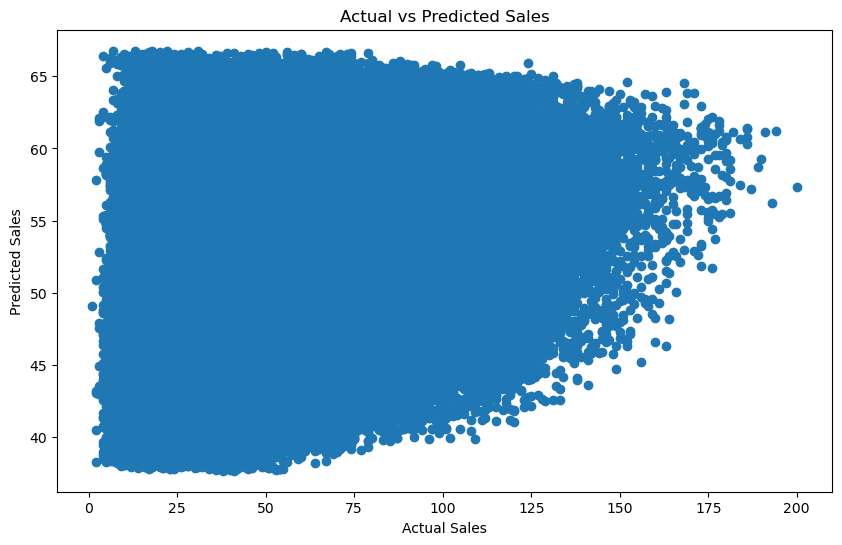

In [47]:
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()

In [48]:
prediction.to_csv("Sales_Predictions.csv", index=False)